In [2]:
import pandas as pd

In [3]:
csv_name = "experiment_v5v6v7_tmux"
folder_path = f'../experiments/{csv_name}/combined_all_algorithms.csv'


df = pd.read_csv(folder_path)
print(df)

      ugv_num  uav_num  poi_num  comm_range  time_poi algorithm
0           2        1        5           5   1695.10        v5
1           2        1        5           5   1654.06        v5
2           2        1        5           5   1623.54        v5
3           2        1        5           5   1287.03        v5
4           2        1        5           5   1049.08        v5
...       ...      ...      ...         ...       ...       ...
1106        2        2       25          20   1410.51        v7
1107        2        2       25          20   1184.52        v7
1108        2        2       25          20   1012.09        v7
1109        2        3       15          10   7329.07        v7
1110        2        3       15          10   2437.57        v7

[1111 rows x 6 columns]


In [4]:
X = df[['ugv_num', 'uav_num', 'poi_num', 'comm_range']]
y = df['time_poi']

In [5]:
from sklearn.linear_model import LinearRegression

model = LinearRegression()
model.fit(X, y)

# Coefficients
print("Intercept:", model.intercept_)
print("Coefficients:", model.coef_)

Intercept: 1392.1092317911975
Coefficients: [-138.58325104   81.26206322   44.62131025    9.73312925]


In [7]:
from sklearn.metrics import r2_score

y_pred = model.predict(X)
print("R² Score:", r2_score(y, y_pred))

R² Score: 0.15589984915944577


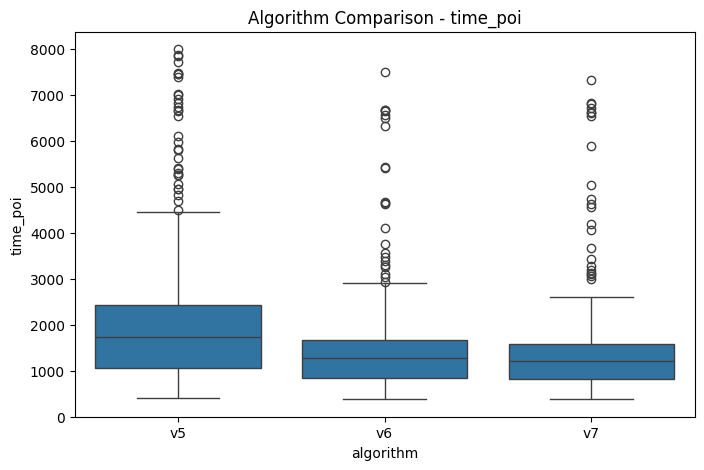

In [11]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.ensemble import RandomForestRegressor
from sklearn.preprocessing import OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.metrics import r2_score
import statsmodels.api as sm
import scipy.stats as stats

# Compare Algorithm Performance
plt.figure(figsize=(8, 5))
sns.boxplot(x="algorithm", y="time_poi", data=df)
plt.title("Algorithm Comparison - time_poi")
plt.show()

In [12]:
print(df.groupby("algorithm")["time_poi"].describe())

           count         mean          std     min      25%      50%      75%  \
algorithm                                                                       
v5         381.0  2103.106220  1547.676000  406.57  1065.54  1730.01  2428.07   
v6         393.0  1445.807786  1045.476674  382.09   832.09  1271.01  1670.52   
v7         337.0  1425.335223  1095.026514  378.03   822.10  1202.52  1583.59   

               max  
algorithm           
v5         7997.07  
v6         7495.07  
v7         7329.07  


In [13]:
anova_result = stats.f_oneway(
    df[df["algorithm"] == "v5"]["time_poi"],
    df[df["algorithm"] == "v6"]["time_poi"],
    df[df["algorithm"] == "v7"]["time_poi"]
)
print("ANOVA F-test p-value:", anova_result.pvalue)

ANOVA F-test p-value: 1.2204134657191834e-15


In [14]:
X = df.drop(columns=["time_poi"])
y = df["time_poi"]

In [15]:
categorical_features = ["algorithm"]
numeric_features = [col for col in X.columns if col not in categorical_features]

In [16]:
preprocessor = ColumnTransformer(
    transformers=[
        ("cat", OneHotEncoder(drop="first"), categorical_features)
    ],
    remainder="passthrough"
)

model = Pipeline(steps=[
    ("preprocessor", preprocessor),
    ("regressor", RandomForestRegressor(random_state=42))
])

model.fit(X, y)

# Feature importance extraction
feature_names = model.named_steps["preprocessor"].get_feature_names_out().tolist() + numeric_features
importances = model.named_steps["regressor"].feature_importances_

importance_df = pd.DataFrame({
    "feature": feature_names,
    "importance": importances
}).sort_values(by="importance", ascending=False)

print("\nFeature Importances:")
print(importance_df)

# Optional: Linear Regression with statsmodels
X_encoded = pd.get_dummies(X, drop_first=True)
X_encoded = sm.add_constant(X_encoded)  # Add intercept term
model_sm = sm.OLS(y, X_encoded).fit()
print("\nOLS Regression Summary:")
print(model_sm.summary())

ValueError: All arrays must be of the same length